In [73]:
from pathlib import Path
import pandas as pd

path = Path("C:\\Users\\Microlab\\Documents\\FALAPHEL-TOT\\falaphel3-daq\\software_batch\\export\\export_matrix_scan_251120_153142_cap50_cap_csa_load.tsv")

if not path.exists():
    raise FileNotFoundError(f"File non trovato: {path.resolve()}")

df = pd.read_csv(path, sep="\t", encoding="utf-8", engine="python")
df.head()

,row,col,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa
0,0,0,95,3.9,0.316,17.8,0.422,1.0,1.0
1,0,0,90,3.3,0.483,18.6,0.966,1.0,1.0
2,0,0,85,3.0,0.000,19.9,0.568,1.0,1.0
3,0,0,80,2.4,0.516,21.5,0.850,1.0,1.0
4,0,0,75,2.1,0.316,24.2,1.033,1.0,1.0


Saved 256 fit records to: C:\Users\Microlab\Documents\FALAPHEL-TOT\falaphel3-daq\software_batch\export\fit_results_per_pixel.csv


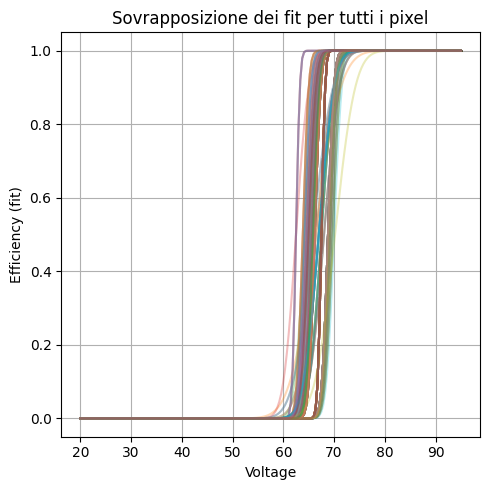

In [74]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd

# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))

cols = ["efficiency_toa"]
results = []

# Per salvare le curve dei fit da plottare dopo
fit_curves = []

# group by pixel (row, col)
for (r, c), group in df.groupby(["row", "col"]):
    x_min, x_max = group["voltage"].min(), group["voltage"].max()
    for col in cols:
        if col not in group.columns:
            continue
        valid = group[["voltage", col]].dropna()
        npts = len(valid)
        if npts < 4:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": np.nan, "dispersion": np.nan, "success": False}
            )
            continue

        xdata = valid["voltage"].values
        ydata = valid[col].values

        guess = [np.median(xdata),
                 max(1.0, (xdata.max() - xdata.min()) / 4.0)]

        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,
            )
            fit_mu, fit_sigma = float(popt[0]), float(popt[1])

            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
            )

            # Salva la curva del fit per il plot finale
            # Uso un vettore x comune per tutti i pixel (uniforme)
            xs = np.linspace(xdata.min(), xdata.max(), 200)
            ys = myERF(xs, fit_mu, fit_sigma)
            fit_curves.append((xs, ys))

        except Exception:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": np.nan, "dispersion": np.nan, "success": False}
            )

# results dataframe
fit_df = pd.DataFrame(results)
fit_out_path = path.parent / "fit_results_per_pixel.csv"
fit_df.to_csv(fit_out_path, index=False)
print(f"Saved {len(fit_df)} fit records to: {fit_out_path}")

# ===============================================
#   PLOT: tutte le S-curve dei fit sovrapposte
# ===============================================
plt.figure(figsize=(5, 5))

for xs, ys in fit_curves:
    plt.plot(xs, ys, alpha=0.3)  # alpha per trasparenza

plt.title("Sovrapposizione dei fit per tutti i pixel")
plt.xlabel("Voltage")
plt.ylabel("Efficiency (fit)")
plt.grid(True)

plt.tight_layout()
plt.show()


Creati 256 record di fit.
Salvato il grafico dei punti sperimentali in 'all_pixels_data_points.png'
Salvato il grafico delle curve di fit in 'all_pixels_fit_curves.png'


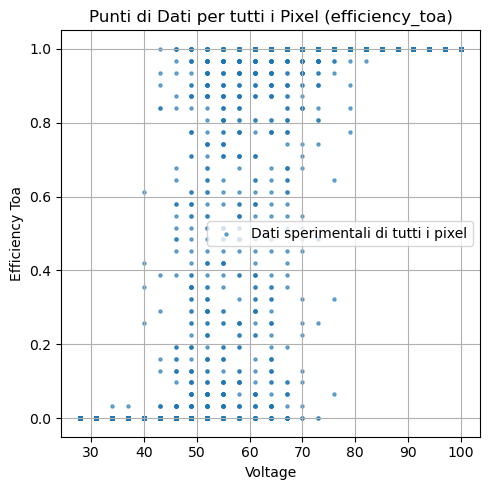

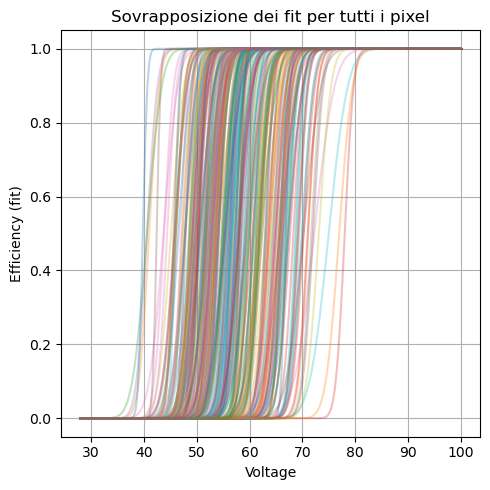

In [38]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd

# ** NUOVA AGGIUNTA **
# Lista per raccogliere tutti i punti (voltage, efficiency_toa)
all_data_points = []
# ** FINE NUOVA AGGIUNTA **

# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))

cols = ["efficiency_toa"]
results = []

# Per salvare le curve dei fit da plottare dopo
fit_curves = []

# group by pixel (row, col)
for (r, c), group in df.groupby(["row", "col"]):
    x_min, x_max = group["voltage"].min(), group["voltage"].max()
    for col in cols:
        if col not in group.columns:
            continue
        valid = group[["voltage", col]].dropna()
        npts = len(valid)
        
        # ** NUOVA AGGIUNTA **
        # Aggiungi i dati validi alla lista di tutti i punti
        if npts >= 4:
            all_data_points.append(valid)
        # ** FINE NUOVA AGGIUNTA **
        
        if npts < 4:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": np.nan, "dispersion": np.nan, "success": False}
            )
            continue

        xdata = valid["voltage"].values
        ydata = valid[col].values

        guess = [np.median(xdata),
                 max(1.0, (xdata.max() - xdata.min()) / 4.0)]

        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,
            )
            fit_mu, fit_sigma = float(popt[0]), float(popt[1])

            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
            )

            # Salva la curva del fit per il plot finale
            xs = np.linspace(xdata.min(), xdata.max(), 200)
            ys = myERF(xs, fit_mu, fit_sigma)
            fit_curves.append((xs, ys))

        except Exception:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts,
                 "threshold": np.nan, "dispersion": np.nan, "success": False}
            )

# results dataframe
fit_df = pd.DataFrame(results)
# Nota: La variabile 'path' non è definita in questo snippet, assumo sia disponibile
# fit_out_path = path.parent / "fit_results_per_pixel.csv"
# fit_df.to_csv(fit_out_path, index=False)
# print(f"Saved {len(fit_df)} fit records to: {fit_out_path}")
print(f"Creati {len(fit_df)} record di fit.")


# ===============================================
#   PLOT: tutti i punti sperimentali (NUOVA SEZIONE)
# ===============================================

if all_data_points:
    # Combina tutti i DataFrame valid in un unico DataFrame
    df_all_points = pd.concat(all_data_points, ignore_index=True)
    
    # Assumiamo che la colonna di efficienza sia cols[0]
    y_col_name = cols[0] 
    
    plt.figure(figsize=(5, 5))
    
    # Plot di tutti i punti come scatter plot
    plt.scatter(
        df_all_points["voltage"], 
        df_all_points[y_col_name], 
        s=5, # dimensione dei punti
        alpha=0.6, 
        label="Dati sperimentali di tutti i pixel"
    )

    plt.title(f"Punti di Dati per tutti i Pixel ({y_col_name})")
    plt.xlabel("Voltage")
    plt.ylabel(y_col_name.replace('_', ' ').title())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    # Salva il plot come immagine
    plt.savefig('all_pixels_data_points.png')
    print("Salvato il grafico dei punti sperimentali in 'all_pixels_data_points.png'")


# ===============================================
#   PLOT: tutte le S-curve dei fit sovrapposte (ESISTENTE)
# ===============================================
plt.figure(figsize=(5, 5))

for xs, ys in fit_curves:
    plt.plot(xs, ys, alpha=0.3)  # alpha per trasparenza

plt.title("Sovrapposizione dei fit per tutti i pixel")
plt.xlabel("Voltage")
plt.ylabel("Efficiency (fit)")
plt.grid(True)

plt.tight_layout()
# Salva il plot come immagine
plt.savefig('all_pixels_fit_curves.png')
print("Salvato il grafico delle curve di fit in 'all_pixels_fit_curves.png'")

In [68]:
def plot_histogram(fit_df, bins, figsize, color, column="threshold"):
    """
    Disegna l'istogramma della colonna specificata dal dataframe dei fit.

    Args:
        fit_df (pd.DataFrame): DataFrame contenente la colonna da plottare.
        bins (int or sequence): Numero di bin o bin edges per l'istogramma.
        figsize (tuple): Dimensione della figura.
        color (str): Colore delle barre.
        column (str): Nome della colonna da plottare (default "threshold").

    Returns:
        (fig, ax): la figure e l'axes creati (None, None se non ci sono dati o colonna mancante).
    """
    if column not in fit_df.columns:
        print(f"Colonna '{column}' non presente in fit_df.")
        return None, None

    data = fit_df[column].dropna()
    if data.empty:
        print(f"Nessun valore in '{column}' disponibile per il plot.")
        return None, None

    mean_val = data.mean()
    std_val = data.std()

    fig, ax = plt.subplots(figsize=figsize)
    ax.hist(data, bins=bins, color=color, alpha=0.7)
    ax.set_title(f"Istogramma di '{column}'")
    ax.set_xlabel(column.replace('_', ' ').title())
    ax.set_ylabel("Frequenza")
    ax.grid(True)

    # annotazione con media e deviazione standard
    ax.annotate(
        f"Media: {mean_val:.2f}\nStd: {std_val:.2f}",
        xy=(0.98, 0.98), xycoords='axes fraction',
        ha='right', va='top',
        bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.6)
    )

    # linee per media e ±1σ
    ax.axvline(mean_val, color='r', linestyle='dashed', linewidth=1,
               label=f'μ')
    ax.axvline(mean_val + std_val, color='b', linestyle='dashed', linewidth=1,
               label=f'±1 σ')
    ax.axvline(mean_val - std_val, color='b', linestyle='dashed', linewidth=1)

    ax.legend(loc='best', fontsize='small')
    fig.tight_layout()
    plt.show()

    return fig, ax


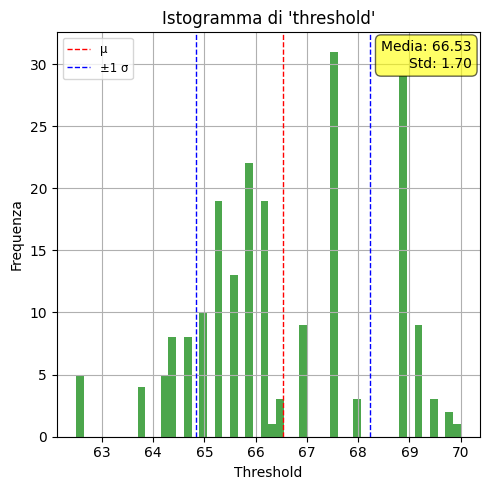

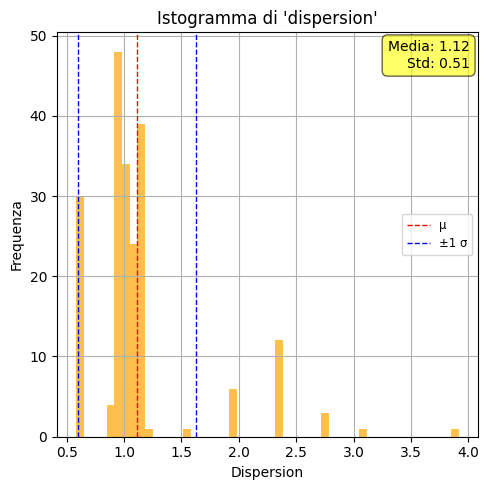

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': "Istogramma di 'dispersion'"}, xlabel='Dispersion', ylabel='Frequenza'>)

In [72]:
plot_histogram(fit_df, 50, (5,5), 'green', column="threshold")
plot_histogram(fit_df, 50, (5,5), 'orange', column="dispersion")

In [6]:

# 1. Funzione ERF (S-Curve)
# Assumiamo che myERF sia definita in questo modo per l'S-curve (integral della Gaussiana)
def myERF(x, mu, sigma):
    """Funzione di errore (ERF) per il fit dell'S-curve."""
    # Modello tipico: 0.5 * (1 + erf((x - mu) / (sigma * sqrt(2))))
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2))))

# 2. Nuova funzione per plottare una singola curva fittata su un oggetto Axes
def plot_single_fit_on_ax(ax, popt, r, c, col):
    """
    Disegna la curva ERF fittata sull'oggetto Axes fornito.
    """
    fit_mu, fit_sigma = popt[0], popt[1]
    
    # Crea 100 punti per un tracciato liscio della curva
    # Utilizza un range arbitrario o basato sui dati se noto
    x_fit = np.linspace(40, 60, 100)  # Modifica questo range se necessario
    y_fit = myERF(x_fit, fit_mu, fit_sigma)
    
    label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
    
    # Aggiungi il plot all'Axes
    ax.plot(x_fit, y_fit, alpha=0.5, label=label)
# 3. Funzione principale per l'elaborazione del DataFrame
def fit_erf_to_scurves(df, cols=["efficiency_toa"], plot_title="Sovrapposizione S-Curves Fittate"):
    """
    Esegue il fit della S-curve ERF sui dati raggruppati per pixel e crea un plot sovrapposto.

    Args:
        df (pd.DataFrame): DataFrame contenente i dati.
        cols (list): Lista delle colonne metriche su cui eseguire il fit.
        plot_title (str): Titolo per il plot di sovrapposizione.

    Returns:
        pd.DataFrame: DataFrame con i risultati del fit (threshold, dispersion, successo).
    """
    results = []
    
    # 3.1. Inizializzazione del plot per la sovrapposizione
    #fig, ax = plt.subplots(figsize=(10, 7))
    #ax.set_title(plot_title)
    #ax.set_xlabel("Voltage (Tensione)")
    #ax.set_ylabel(f"Fit S-Curve ({', '.join(cols)})")
    
    # 3.2. Raggruppa i dati per pixel (row, col)
    for (r, c), group in df.groupby(["row", "col"]):
        
        # Itera su tutte le colonne metriche specificate
        for col in cols:
            if col not in group.columns:
                continue

            # Prepara i dati
            valid = group[["voltage", col]].dropna()
            npts = len(valid)

            # Controllo minimo punti per il fit
            if npts < 4:
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )
                continue

            xdata = valid["voltage"].values
            ydata = valid[col].values

            # Stima iniziale dei parametri (guess)
            guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
            
            # 3.3. Esegue il fit
            try:
                popt, pcov = curve_fit(
                    myERF,
                    xdata,
                    ydata,
                    p0=guess,
                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                    maxfev=5000,
                )
                fit_mu, fit_sigma = float(popt[0]), float(popt[1])
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
                )

                # 3.4. Aggiunge il fit al plot di sovrapposizione
                plot_single_fit_on_ax(ax, popt, r, c, col)
                
            except Exception as e:
                # Gestione dell'errore nel fit
                print(f"Fit fallito per pixel ({r}, {c}), metrica {col}: {e}")
                results.append(
                    {"row": r, "col": c, "metric": col, "n_points": npts, 
                     "threshold": np.nan, "dispersion": np.nan, "success": False}
                )

    # 3.5. Finalizzazione del plot (dopo il ciclo)
    # Rimuovi il codice per la legenda se il numero di curve è elevato, 
    # altrimenti potrebbe rendere il plot illeggibile.
    # Se vuoi solo un'idea della distribuzione, non mettere la legenda.
    
    # ax.legend(loc='best', fontsize='small') # Abilita se hai pochi pixel
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Salva il plot in un file (opzionale)
    #plt.savefig(f"{'_'.join(cols)}_overlapped_fits.png")
    
    # Mostra il plot (opzionale)
    plt.show() 
    
    plt.close(fig) # Chiudi la figura per liberare memoria

    # 3.6. Ritorna il DataFrame dei risultati
    return pd.DataFrame(results)

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\764190429.py:20: SyntaxWarning: invalid escape sequence '\m'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"
C:\Users\andre\AppData\Local\Temp\ipykernel_13344\764190429.py:20: SyntaxWarning: invalid escape sequence '\s'
  label = f"Pixel ({r}, {c}) - $\mu$={fit_mu:.2f}, $\sigma$={fit_sigma:.2f}"


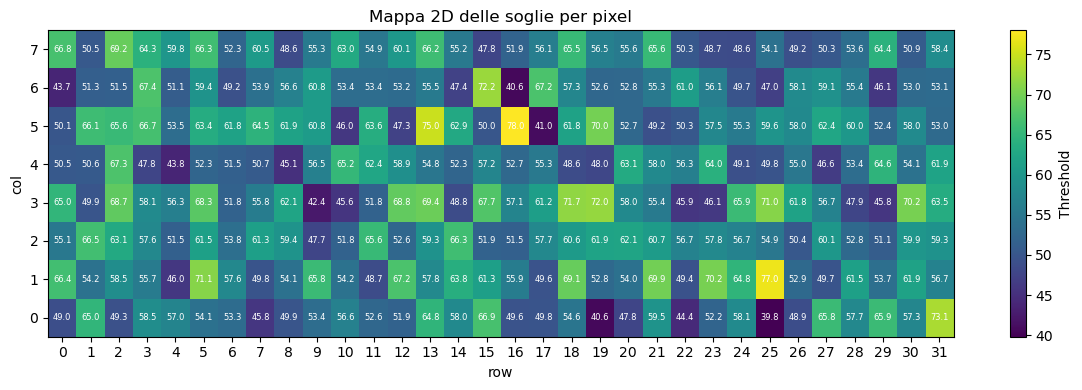

In [7]:
# Crea la mappa 2D delle soglie per pixel
n_row = int(fit_df["row"].max()) + 1
n_col = int(fit_df["col"].max()) + 1
thr_map = np.full((n_col, n_row), np.nan)  # note: rows=col, cols=row

for _, r in fit_df.iterrows():
    # pos: (original col, original row)
    thr_map[int(r["col"]), int(r["row"])] = r["threshold"] if r.get("success", True) else np.nan

masked = np.ma.masked_invalid(thr_map)
cmap = cmap if 'cmap' in globals() else plt.cm.viridis.copy()
try:
    cmap = cmap.copy()
    cmap.set_bad(color="lightgray")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

# ora asse X = row (original), asse Y = col (original)
ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))

# etichette più sparse se troppe
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold")

# annota valori (attento: molti pixel -> disabilitare)
for i in range(n_col):       # i corrisponde all'originale col
    for j in range(n_row):   # j corrisponde all'originale row
        v = thr_map[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6, color="white")

ax.set_title("Mappa 2D delle soglie per pixel")
plt.tight_layout()
plt.show()

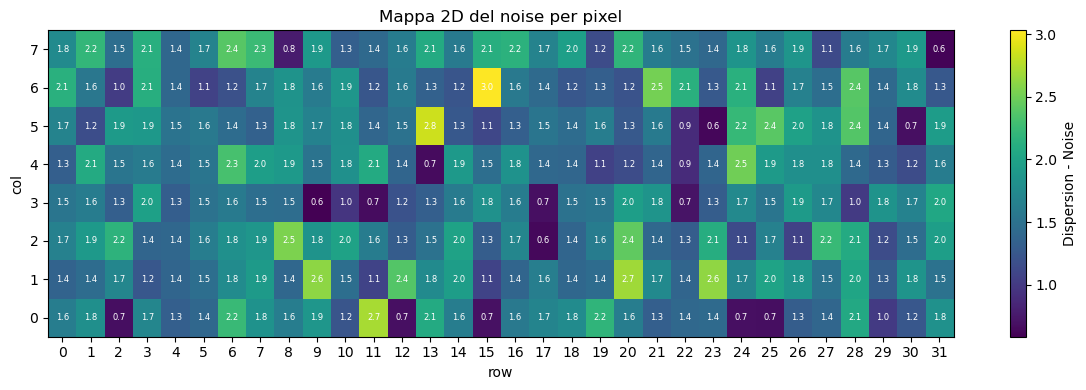

In [8]:
# Crea la mappa 2D del noise per pixel
n_row = int(fit_df["row"].max()) + 1
n_col = int(fit_df["col"].max()) + 1
thr_map = np.full((n_col, n_row), np.nan)  # note: rows=col, cols=row

for _, r in fit_df.iterrows():
    # pos: (original col, original row)
    thr_map[int(r["col"]), int(r["row"])] = r["dispersion"] if r.get("success", True) else np.nan

masked = np.ma.masked_invalid(thr_map)
cmap = cmap if 'cmap' in globals() else plt.cm.viridis.copy()
try:
    cmap = cmap.copy()
    cmap.set_bad(color="lightgray")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

# ora asse X = row (original), asse Y = col (original)
ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))

# etichette più sparse se troppe
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Dispersion - Noise")

# annota valori (attento: molti pixel -> disabilitare)
for i in range(n_col):       # i corrisponde all'originale col
    for j in range(n_row):   # j corrisponde all'originale row
        v = thr_map[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6, color="white")

ax.set_title("Mappa 2D del noise per pixel")
plt.tight_layout()
plt.show()